<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            border-left: 5px solid #1f77b4; 
            padding: 20px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05); 
            max-width: 800px; 
            margin-bottom: 25px;">
    
<h1 style="color: #212529; margin-top: 0; margin-bottom: 5px; font-size: 26px; font-weight: 700;">
    Part I: Simplified CMS Open Data
</h1>
<br>
<p style="color: #6c757d; margin-top: 0; margin-bottom: 20px; font-size: 18px; font-weight: bold;">
    Notebook 3: $Z \rightarrow \mu^+\mu^-$ Reconstruction
</p>

<hr style="border: 0; border-top: 1px solid #dee2e6; margin-bottom: 15px;">

<table style="border-collapse: collapse; width: 100%; font-size: 14px; line-height: 1.6;">
    <tr>
        <td style="padding: 4px 0; width: 150px; font-weight: bold; color: #495057;">Author:</td>
        <td style="padding: 4px 0; color: #212529;">Uditangshu Roy</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Affiliation:</td>
        <td style="padding: 4px 0; color: #212529;">Undergraduate, Department of Physics and Astronomy, The University of Manchester</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Contact:</td>
        <td style="padding: 4px 0; color: #1f77b4; text-decoration: none;">roy.uditangshu@gmail.com</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Date:</td>
        <td style="padding: 4px 0; color: #212529;">August 2026</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Dataset Source:</td>
        <td style="padding: 4px 0; color: #212529;">CERN Open Data: <i> Z to two muons from 2011</i>. McCauley, T. Recorded 2011. Published 2019.</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Software Env.:</td>
        <td style="padding: 4px 0; color: #212529;">Python 3.11+, Pandas, Matplotlib, NumPy, Pathlib, IPython</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">ORCID:</td>
        <td style="padding: 4px 0; color: #212529; font-family: monospace; letter-spacing: 0.5px;"><a href="https://orcid.org/0009-0005-7992-3549">0009-0005-7992-3549</a></td>
    </tr>
</table>
</div>

## 1. &nbsp; Introduction

Having established the quality and physical consistency of the reconstructed muon observables, the next stage of the analysis is to reconstruct the invariant mass of the parent particle responsible for producing the observed muon pair. In high-energy collider physics, the invariant mass is one of the most powerful kinematic quantities, as it is independent of the reference frame and enables unstable particles to be identified through their decay products.

In this notebook, the invariant mass of each reconstructed dimuon event is calculated using two independent approaches. The first employs the full relativistic energy–momentum relation, retaining the finite rest mass of the muon throughout the calculation. The second applies the widely used massless approximation, in which the muon mass is neglected because it is several orders of magnitude smaller than the typical energies observed at the LHC. The reconstructed mass spectra obtained from both methods are then compared to assess the validity of the approximation and to identify the characteristic resonance corresponding to the $Z$- boson.

In [1]:
#Import libraries and modules

import sys
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fourvectors import (
    invariant_mass_exact,
    invariant_mass_massless
)

from src.plotting import (
    set_plot_style,
    histogram_peak,
    plot_histogram
)

from src.particles import *

from src.utilities import TABLE_STYLES

set_plot_style()  #sets matplotlib rc-params

#Center-align outputs
display(HTML("""
<style>
.jp-OutputArea-output {
    display: flex;
    justify-content: center;
    align-items: center;
}
</style>
"""))

In [2]:
#Load Dataset
zmumu = pd.read_csv("../../data/raw/simplified/zmumu_10k.csv")

## 2. &nbsp; Relativistic Four-Momentum and Invariant Mass

The reconstruction of the invariant mass begins with the relativistic four-momentum of each reconstructed muon. In special relativity, the four-momentum combines the particle's energy and three-momentum into a single Lorentz-invariant quantity, allowing physical observables to be calculated independently of the observer's reference frame. Since the CMS detector measures the momentum components of each particle, these measurements can be combined to determine the invariant mass of the parent particle from which the muons originated.

### 2.1 &nbsp; Exact Invariant Mass Derivation

The relativistic four-momentum of the $i$-th particle is mathematically defined as $P_i^{\mu} = (E_i,\: \vec{P_i})$. In natural units, i.e., $c = 1$, the invariant mass $M$ is defined by $M^2 = (P_1 + P_2)^2$, where for the $i$-th particle, $P_i^2 = P_{i \mu} P_i^{\mu} $ is the four-vector inner product of the four-momentum with itself.

Expanding on the square, and substituting the magnitude of the four-momenta from the energy-momentum relations defined above, and after some algebraic manipulations, one arrives at the following:
$$ M^2 = (E_1 + E_2)^2 - |\vec{p}_1 + \vec{p}_2|^2 \:. \tag{1} $$

The components of the three-momentum, $p_x$, $p_y$ and $p_z$, are represented in terms of the transverse momentum ($p_T$, perpendicular component of $\vec{p}$), the azimuthal angle ($\phi$) and the pseudorapidity ($\eta$). Therefore, $\vec{p}$ can be presented as:
$$ \vec{p} = \begin{pmatrix} \: p_{T} \cos{\phi} \: \\ \: p_{T} \sin{\phi} \: \\ \: p_{T} \sinh{\eta} \: \end{pmatrix}. \tag{2} $$
In terms of momentum, pseudorapidity can be defined as $\eta = \tanh^{-1} \left( \frac{p_L}{|\vec{p}|} \right)$, where $p_L = p_Z = |\vec{p}| \cos{\phi}$ is the longitudinal momentum.

Therefore, the squared magnitude of three-momentum can be defined as the sum of its transverse and longitudinal components: $|\vec{p}|^2 = p_T^2 + p_Z^2$. Substituing the relation for $p_Z$ in terms of hyperbolic sine, and simplifying, one can obtain the expression $|\vec{p}|^2 = p_T^2 \cosh^2{\eta}$

Next, we compute the inner product of the three-momenta of the two muons. It is known that $\vec{p_1} \cdot \vec{p_2} = \sum_{i} p_{1_i} p_{2_i}$. Upon substituing the previously defined expressions for the individual components in eq. (2), and performing some algebraic and trigonometric simplifications, one finds that:
$$ \vec{p}_1 \cdot \vec{p}_2 = p_{T1} p_{T2} \left[ \cos(\phi_1 - \phi_2) + \sinh\eta_1 \sinh\eta_2 \right] \:. \tag{3} $$

Using the relation $E_i^2 = m_i^2 + |\vec{p}_i|^2$ for the energy of the $i$-th particle of mass $m_i$, eq.(1) can be re-written as:
$$ M^2 = m_1^2 + m_2^2 + 2 \left( E_1E_2 - \vec{p}_1 \cdot \vec{p}_2 \right) \tag{4} \:. $$

Since the muons have identical masses, i.e., $m_1 = m_2 = m_{\mu}$, the exact invariant mass expression thus becomes:
$$ M_{inv,\, exact} = \sqrt {2 \left( m^2_{\mu} + E_1E_2 - \vec{p}_1 \cdot \vec{p}_2 \right)} \tag{5} \:, $$
where, for computational purposes, the inner product of three-momenta can be computed using eq. (3) and the energies using the aforementioned relation in terms of mass and momentum. The rest mass energy of the muon is taken as $105.6583755 \: \text{MeV}$, with a standard uncertainty of $0.0000023 \: \text{MeV}$ [1]. This is exceptionally small, with a relative standard uncertainty of just $2.2 \times 10^{-8}$.

### 2.2 &nbsp; Massless Approximation of Invariant Mass

At LHC energies, the momentum of each reconstructed muon is typically several hundred times larger than its rest mass. Consequently, the muon may be approximated as a massless particle, allowing the invariant mass expression to be simplified considerably. Hence, one can consider $m_{\mu} \approx 0$, and thus expression for the energy of the $i$-th particle simplifies to $E_i = |\vec{p}_i|$. Then, eq. (5) can be simplified by substituing expressions for the energies in terms of momenta, followed by some further algebraic, trigonometric and hyperbolic manipulations. The resultant massless approximation of invariant mass expression is thus:

$$ M_{inv,\, approx.} = \sqrt {2 \, p_{T1} p_{T2} \left\{ \cosh(\eta_1 - \eta_2) - \cos(\phi_1 - \phi_2) \right\}} \tag{6} \:. $$

## 3. &nbsp; Invariant Mass Reconstruction

### 3.1 &nbsp; Exact Invariant Mass

The exact invariant mass calculation retains the finite rest mass of the muon throughout the reconstruction. Although the muon mass is small compared with its typical momentum at LHC energies, including the full relativistic expression provides the most complete description of the event kinematics and serves as a benchmark against which approximate methods can be compared.

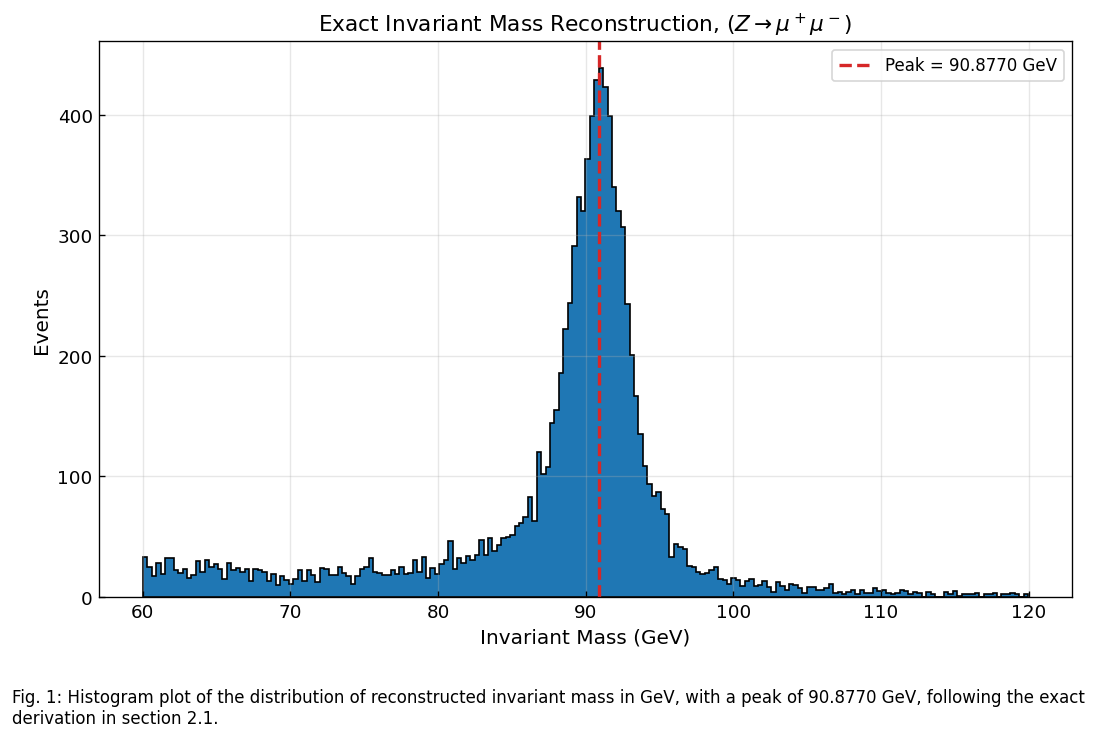

In [3]:
M_inv_exact = invariant_mass_exact(zmumu, MUON_REST_MASS)

peak_exact = histogram_peak(M_inv_exact)

plot_histogram(
    M_inv_exact,
    bins=200,
    xlabel="Invariant Mass (GeV)",
    title=r"Exact Invariant Mass Reconstruction, ($Z \rightarrow \mu^+\mu^-$)",
    color="#1f77b4",
    vlines=[(peak_exact, f"Peak = {peak_exact:.4f} GeV", "#d62728")],
    caption=f"Fig. 1: Histogram plot of the distribution of reconstructed invariant mass in GeV, with a peak of {peak_exact:.4f} GeV, following the exact derivation in section 2.1.",
    save_path="../../figures/z_mumu_exact_mass_reconstruction_part_1.png",
    alt_caption=f"""Histogram plot of the distribution of reconstructed invariant mass of the $Z \\rightarrow \\mu^- \\mu^+$ sample in GeV, illustrated in blue, \
following the exact invariant mass derivation in notebook 3, section 2.1, without any approximations. The dashed red line depicts the peak of the histogram at {peak_exact:.4f} GeV.
"""
)

### 3.2 &nbsp; Massless Approximation

At LHC energies, the momentum of each reconstructed muon is typically several hundred times larger than its rest mass. Consequently, the muon may be approximated as a massless particle, allowing the invariant mass expression to be simplified considerably. This approximation is widely employed in experimental particle physics because it reduces the computational complexity while introducing only a negligible error in the reconstructed mass.

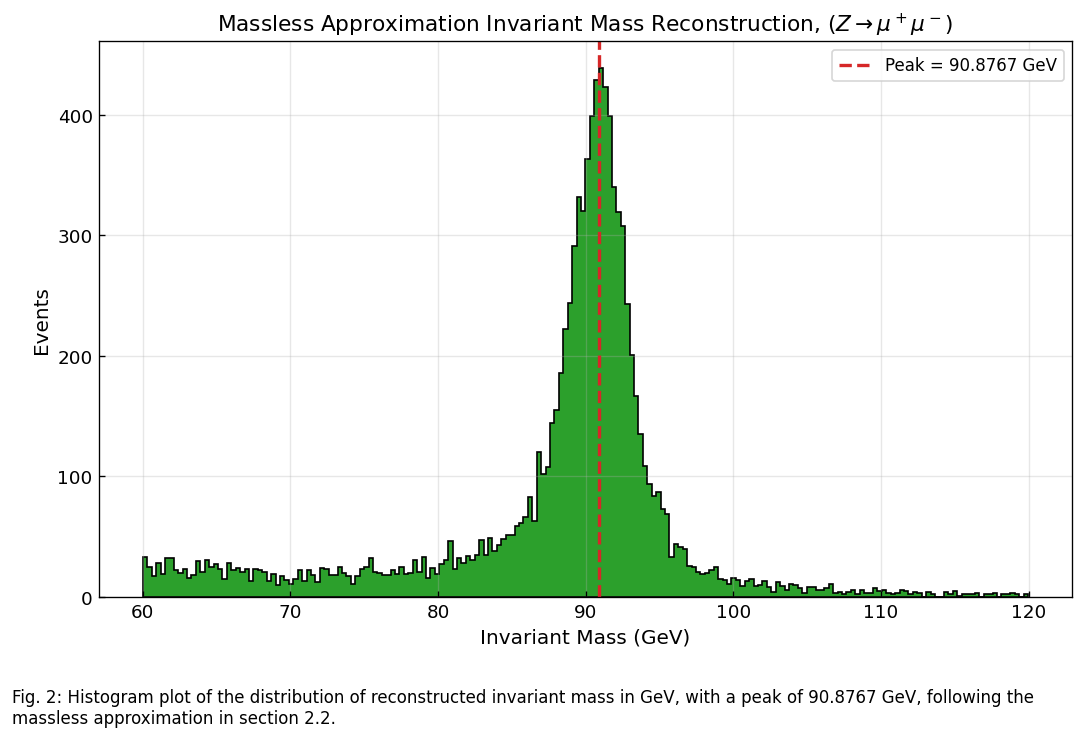

In [4]:
M_inv_massless = invariant_mass_massless(zmumu)

peak_massless = histogram_peak(M_inv_massless)

plot_histogram(
    M_inv_massless,
    bins=200,
    xlabel="Invariant Mass (GeV)",
    title=r"Massless Approximation Invariant Mass Reconstruction, ($Z \rightarrow \mu^+\mu^-$)",
    color="#2ca02c",
    vlines=[(peak_massless, f"Peak = {peak_massless:.4f} GeV", "#d62728")],
    caption=f"Fig. 2: Histogram plot of the distribution of reconstructed invariant mass in GeV, with a peak of {peak_massless:.4f} GeV, following the massless approximation in section 2.2.",
    save_path="../../figures/z_mumu_massless_approx_reconstruction_part_1.png",
    alt_caption=f"""Histogram plot of the distribution of reconstructed invariant mass of the $Z \\rightarrow \\mu^- \\mu^+$ sample in GeV, illustrated in green, \
following the massless approximation derived in notebook 3, section 2.2, which assumes a negligible muon rest mass ($M_{{\\mu}} \\approx 0$). \
The dashed red line depicts the peak of the histogram at {peak_massless:.4f} GeV.
"""
)

## 4. &nbsp; Comparison of Reconstruction Methods

The exact relativistic reconstruction and the massless approximation each produced an invariant mass value for every reconstructed dimuon event. Given the muon's negligible rest mass (in order of MeV) in comparison to the typical energies of tens of GeV, only extremely small differences are expected between the two reconstruction methods. This section quantifies these differences by comparing the reconstructed invariant masses on an event-by-event basis and evaluating the positions of the reconstructed $Z$-boson invariant mass.

### 4.1 &nbsp; Statistical Comparison

In [5]:
#Display comparison

diff_array = np.abs(M_inv_exact - M_inv_massless)  #Difference in two methods

mean_diff= np.mean(diff_array)
max_diff  = np.max(diff_array)
min_diff  = np.min(diff_array)
peak_diff = np.abs(peak_exact - peak_massless)

stat_data = {
    "Quantity": [
        "Mean Absolute Difference", 
        "Maximum Difference", 
        "Minimum Difference", 
        "Exact Peak Position", 
        "Massless Approx. Peak Position", 
        "Peak Difference"
    ],
    "Value (GeV)": [
        mean_diff, 
        max_diff, 
        min_diff, 
        peak_exact, 
        peak_massless, 
        peak_diff
    ]
}

df = pd.DataFrame(stat_data)

stat_table_styles = [
    dict(selector="th", props=[
        ("text-align", "center"),
        ("background-color", "#f8f9fa"),
        ("color", "#333333"),
        ("font-weight", "bold"),
        ("border-bottom", "2px solid #dee2e6"),
        ("padding", "10px")
    ]),
    dict(selector="td", props=[
        ("padding", "8px 12px"),
        ("border-bottom", "1px solid #f1f3f5")
    ]),
    dict(selector="tr:hover", props=[
        ("background-color", "#f1f3f5")
    ]),
   
    TABLE_STYLES
]

stats_comparison_table = (
    df.style
    .format({"Value (GeV)": "{:.6f}"})
    .hide(axis="index")
    .set_table_styles(TABLE_STYLES)
    .set_caption("<b>Table 1:</b> Statistical comparison between exact and massless approximation methods.")
)

stats_comparison_table

Quantity,Value (GeV)
Mean Absolute Difference,0.000307
Maximum Difference,0.007206
Minimum Difference,0.000188
Exact Peak Position,90.877033
Massless Approx. Peak Position,90.876733
Peak Difference,0.000299


### 4.2 &nbsp; Event-by-Event Difference

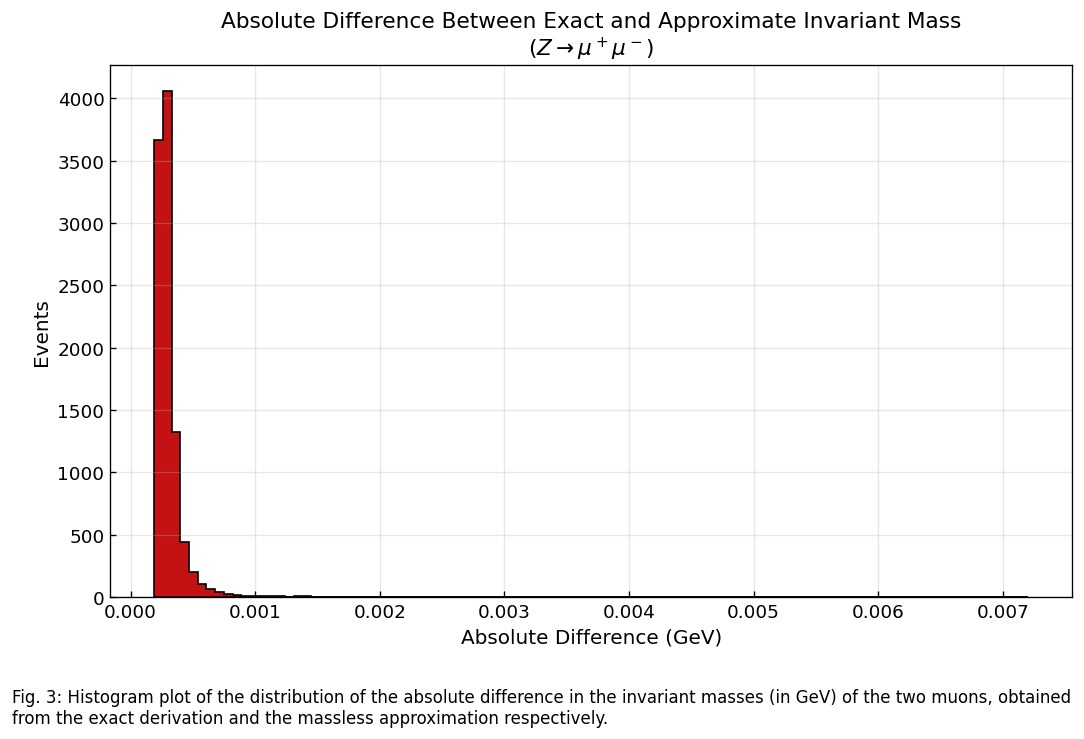

In [6]:
plot_histogram(
    diff_array,
    bins=100,
    xlabel="Absolute Difference (GeV)",
    color="#c41114",
    title=("Absolute Difference Between Exact and Approximate Invariant Mass\n" +
          r"($Z \rightarrow \mu^+\mu^-$)"
    ),
    caption=f"Fig. 3: Histogram plot of the distribution of the absolute difference in the invariant masses (in GeV) of the two muons, obtained from the exact derivation and the massless approximation respectively."
)

The event-by-event comparison demonstrates that the invariant masses reconstructed using the exact relativistic expression and the massless approximation differ by only a very small amount. The distribution of absolute differences is strongly concentrated near zero, with the vast majority of events lying between $0$ and $0.001 \, \text{GeV}$, followed by a rapidly decreasing tail extending slightly beyond that. This indicates that only a small fraction of events exhibit slightly larger deviations, while almost all events show differences at the sub-MeV level.

As shown in section 4.1, the mean absolute difference between the two methods is approximately $3.07 \times 10^{-4} \, \text{GeV}$, corresponding to roughly $0.3 \, \text{MeV}$. Even the largest observed deviation within the entire dataset is only $7.21 \times 10^{-3} \, \text{GeV}$, or approximately $7 \, \text{MeV}$.

Moreover, the reconstructed invariant mass spectra obtained using the exact relativistic calculation and the massless approximation are virtually indistinguishable. Both methods produce a pronounced peak centred at approximately $90.88 \, \text{GeV}$, with the peak positions differing by only $2.99 \times 10^{-4} \, \text{GeV}$. This difference is approximately three hundred thousand times smaller than the reconstructed $Z$-boson mass itself and is therefore entirely negligible for practical analyses. The close agreement between the two methods demonstrates that the small but finite rest mass of the muon contributes only a minute correction to the invariant mass at the energies considered here, thus confirming that the massless approximation provides an excellent description of the event kinematics under LHC high-energy conditions.

### 4.3 &nbsp; Comparison with the Accepted Peak Value

The invariant mass spectrum reconstructed from the simplified CMS Open Data exhibits a clear resonance centred at approximately $90.88 \, \text{GeV}$, corresponding to the production of the $Z$-boson. This reconstructed value differs from the accepted Particle Data Group value of $91.1879 \, \text{GeV}$ [2] by approximately $0.31 \, \text{GeV}$, representing a relative deviation of only $0.34 \%$.

This small discrepancy is expected and does not indicate an error in the reconstruction procedure. The dataset used in this project is a simplified educational sample rather than the complete CMS experimental dataset, and therefore does not incorporate the full detector calibration, alignment, momentum corrections or sophisticated event reconstruction algorithms employed in precision measurements. Furthermore, the peak position has been estimated from a binned histogram, meaning that its exact value is influenced slightly by the chosen bin width. Despite these limitations, the reconstructed resonance lies in excellent agreement with the accepted $Z$-boson mass and demonstrates that the invariant mass reconstruction has been successfully implemented.


### 4.4 &nbsp; Saving Results
This section performs the necessary computations to save and store the results obtained from the dimuon events data in a csv file format, in the path <code>../../data/processed/dimuon_part_1_summary.csv</code>. The large array of the entire distribution of the invariant mass is stored using NumPy's binary format, as <code>../../data/interim/dimuon_part_1_exact_mass.npy</code>.

In [7]:
#Save the final computed results
results = pd.DataFrame({
    "Quantity": [
        "Exact Peak",
        "Approximate Peak",
        "Peak Difference",
        "Mean Approximation Error",
        "Maximum Approximation Error",
        "Minimum Approximation Error",
        "Difference from PDG Value"
    ],
    "Value (GeV)": [
        peak_exact,
        peak_massless,
        peak_diff,
        mean_diff,
        max_diff,
        min_diff,
        np.abs(peak_exact - PDG_Z_MASS)
    ]
})

results.to_csv("../../data/processed/dimuon_part_1_summary.csv", index=False)


#Save the exact invariant mass distribution
np.save("../../data/interim/dimuon_part_1_exact_mass.npy", M_inv_exact)

## 5 &nbsp; Conclusion

This notebook has successfully reconstructed the invariant mass of the $Z$ boson from pairs of reconstructed muons contained within the simplified CMS Open Data sample. Beginning from the relativistic four-momentum formalism, the invariant mass was calculated using both the exact relativistic expression, retaining the finite muon rest mass, and the widely adopted massless approximation. Both approaches produced a clear resonance corresponding to the $Z$-boson decay, demonstrating that the reconstruction procedure has been implemented correctly.

A direct comparison of the two methods showed excellent agreement across the entire dataset. The mean event-by-event difference between the reconstructed invariant masses was found to be approximately $3.07 \times 10^{-4}\,\text{GeV}$, while the reconstructed resonance positions differed by only $2.99 \times 10^{-4}\,\text{GeV}$. These differences are negligible when compared with both the characteristic energy scale of the process and the experimental resolution of the detector, confirming that the massless approximation provides an exceptionally accurate description of relativistic muons produced at LHC energies.

The reconstructed resonance was observed at approximately $90.88 \, \text{GeV}$, lying within $0.34 \%$ of the accepted Particle Data Group value of $91.1879 \, \text{GeV}$ [2]. This level of agreement demonstrates the reliability of the reconstruction while illustrating the expected limitations associated with a simplified educational dataset, finite histogram binning and the absence of the full calibration and reconstruction procedures employed in precision CMS analyses.

Overall, this notebook establishes a complete computational framework for invariant mass reconstruction using reconstructed detector observables. The methods developed here form the foundation for the second part of this project, in which the full CMS Open Data sample will be analysed using more realistic event selection criteria, detector-quality requirements and advanced reconstruction techniques, providing a closer approximation to a genuine experimental particle physics analysis.

## References

[1] <https://physics.nist.gov/cgi-bin/cuu/Value?mmuc2mev>. _CODATA value: muon mass energy equivalent in MeV_¸ National Institute of Standards and Technology, U.S. Department of Commerce. 2022. Date accessed 23/07/2026. <br>
[2] <https://pdg.lbl.gov/2026/listings/rpp2026-list-z-boson.pdf>. Takahashi, F. _et al_. Particle Data Group. Int. J. Mod. Phys. A 41, 2630011 (2026)